In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

path = '/content/drive/MyDrive/Data Analyst/EduSmart/data/cleaned'

dim_courses = pd.read_csv(f'{path}/dim_courses_cleaned.csv')
dim_instructors = pd.read_csv(f'{path}/dim_instructors_cleaned.csv')
fact_enrollments = pd.read_csv(f'{path}/fact_enrollments_cleaned.csv')
fact_progress = pd.read_csv(f'{path}/fact_progress_cleaned.csv')
fact_reviews = pd.read_csv(f'{path}/fact_reviews_cleaned.csv')

print("Data cleaned berhasil dimuat.")

Mounted at /content/drive
Data cleaned berhasil dimuat.


In [ ]:
# Hitung completion status per enrollment
progress_summary = fact_progress.groupby('enrollment_id').agg(
    modul_completed=('status', lambda x: (x == 'completed').sum())
).reset_index()

enrollment_full = fact_enrollments.merge(progress_summary, on='enrollment_id', how='left')
enrollment_full = enrollment_full.merge(dim_courses[['course_id','instructor_id','total_modules']], on='course_id')
enrollment_full['modul_completed'] = enrollment_full['modul_completed'].fillna(0)
enrollment_full['is_completed'] = enrollment_full['modul_completed'] >= enrollment_full['total_modules']

# Completion rate per instruktur
completion_per_instructor = enrollment_full.groupby('instructor_id').agg(
    total_enrollment=('enrollment_id', 'count'),
    completion_rate=('is_completed', lambda x: x.mean() * 100)
).reset_index()

# Rating rata-rata per instruktur
review_with_instructor = fact_reviews.merge(
    fact_enrollments[['enrollment_id','course_id']], on='enrollment_id'
).merge(
    dim_courses[['course_id','instructor_id']], on='course_id'
)

rating_per_instructor = review_with_instructor.groupby('instructor_id').agg(
    jumlah_review=('rating', 'count'),
    rata_rata_rating=('rating', 'mean')
).reset_index()

# Gabungkan, filter sampel cukup besar (sama seperti SQL: enrollment>=10, review>=5)
data_korelasi = completion_per_instructor.merge(rating_per_instructor, on='instructor_id')
data_korelasi = data_korelasi[(data_korelasi['total_enrollment'] >= 10) & (data_korelasi['jumlah_review'] >= 5)]

print(f"Jumlah instruktur setelah filter: {len(data_korelasi)}")
data_korelasi.head()

Jumlah instruktur setelah filter: 60


,instructor_id,total_enrollment,completion_rate,jumlah_review,rata_rata_rating
0,1,105,33.333333,44,4.136364
1,2,129,27.131783,53,4.018868
2,3,79,32.911392,49,4.306122
3,4,194,30.412371,105,4.009524
4,5,26,23.076923,10,3.900000


In [ ]:
# Hitung Pearson correlation + p-value
korelasi, p_value = stats.pearsonr(data_korelasi['rata_rata_rating'], data_korelasi['completion_rate'])

print(f"Koefisien korelasi Pearson: {korelasi:.4f}")
print(f"P-value: {p_value:.4f}")
print(f"Jumlah instruktur (n): {len(data_korelasi)}")

if p_value < 0.05:
    print("\nKesimpulan: Korelasi SIGNIFIKAN secara statistik (p < 0.05)")
else:
    print("\nKesimpulan: Korelasi TIDAK signifikan secara statistik (p >= 0.05)")
    print("-> Tidak cukup bukti untuk mengatakan ada hubungan antara rating dan completion rate")

print(f"\nValidasi silang dengan SQL: hasil SQL sebelumnya = -0.008")
print(f"Hasil Python: {korelasi:.4f} -- {'COCOK' if abs(korelasi - (-0.008)) < 0.01 else 'BERBEDA, perlu dicek'}")

Koefisien korelasi Pearson: -0.0080
P-value: 0.9518
Jumlah instruktur (n): 60

Kesimpulan: Korelasi TIDAK signifikan secara statistik (p >= 0.05)
-> Tidak cukup bukti untuk mengatakan ada hubungan antara rating dan completion rate

Validasi silang dengan SQL: hasil SQL sebelumnya = -0.008
Hasil Python: -0.0080 -- COCOK


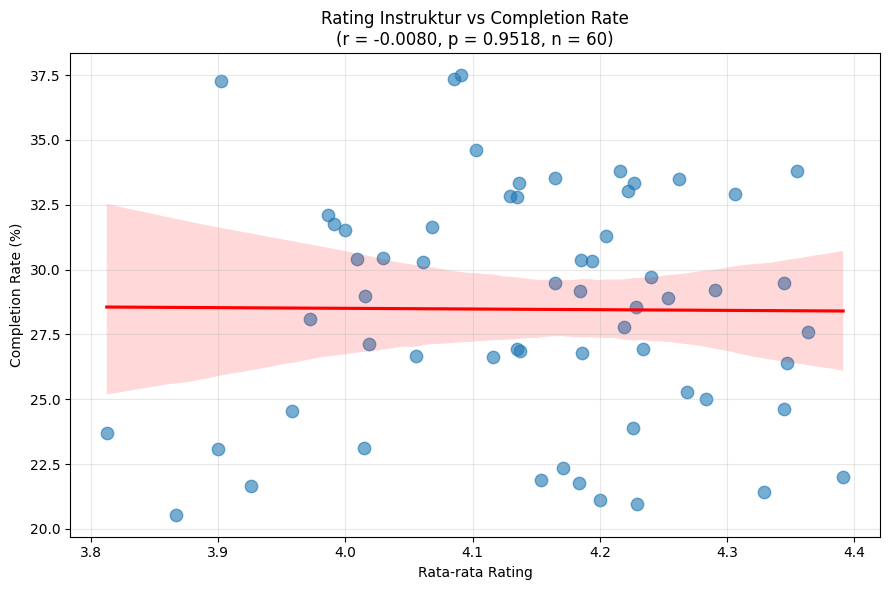

In [ ]:
fig, ax = plt.subplots(figsize=(9, 6))
sns.regplot(data=data_korelasi, x='rata_rata_rating', y='completion_rate',
            scatter_kws={'alpha':0.6, 's':80}, line_kws={'color':'red'}, ax=ax)
ax.set_title(f'Rating Instruktur vs Completion Rate\n(r = {korelasi:.4f}, p = {p_value:.4f}, n = {len(data_korelasi)})')
ax.set_xlabel('Rata-rata Rating')
ax.set_ylabel('Completion Rate (%)')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
dokumentasi_korelasi = """
=== RINGKASAN CORRELATION ANALYSIS (04_correlation_analysis.ipynb) ===

Analisis: Korelasi Pearson antara rata-rata rating instruktur dan
completion rate kursus mereka, n=60 instruktur (filter: total_enrollment
>=10, jumlah_review >=5).

HASIL:
- Koefisien korelasi Pearson: -0.0080 (praktis nol)
- P-value: 0.9518 (jauh di atas ambang 0.05 -- TIDAK signifikan)
- Validasi silang dengan query SQL (04_rating_correlation.sql): identik (-0.008)

KESIMPULAN: Tidak ada cukup bukti statistik untuk mengatakan ada hubungan
antara rating instruktur dan completion rate kursus mereka. Rating TIDAK
bisa dipakai sebagai proxy atau prediktor completion rate. Menjawab
Pertanyaan Bisnis #3 di Project Brief secara definitif.
"""
print(dokumentasi_korelasi)

log_path = '/content/drive/MyDrive/Data Analyst/EduSmart'
with open(f'{log_path}/data_cleaning_log.txt', 'a') as f:
    f.write(dokumentasi_korelasi)
print("Dokumentasi correlation analysis ditambahkan ke data_cleaning_log.txt")


=== RINGKASAN CORRELATION ANALYSIS (04_correlation_analysis.ipynb) ===

Analisis: Korelasi Pearson antara rata-rata rating instruktur dan
completion rate kursus mereka, n=60 instruktur (filter: total_enrollment
>=10, jumlah_review >=5).

HASIL:
- Koefisien korelasi Pearson: -0.0080 (praktis nol)
- P-value: 0.9518 (jauh di atas ambang 0.05 -- TIDAK signifikan)
- Validasi silang dengan query SQL (04_rating_correlation.sql): identik (-0.008)

KESIMPULAN: Tidak ada cukup bukti statistik untuk mengatakan ada hubungan
antara rating instruktur dan completion rate kursus mereka. Rating TIDAK
bisa dipakai sebagai proxy atau prediktor completion rate. Menjawab
Pertanyaan Bisnis #3 di Project Brief secara definitif.

Dokumentasi correlation analysis ditambahkan ke data_cleaning_log.txt
